# Ноутбук для переходу від Python-скриптів до Jupyter

Цей ноутбук показує, як імпортувати, запускати та налагоджувати існуючі Python-скрипти у VSCode, а також як організувати роботу з проектом у інтерактивному середовищі.

## 1. Імпорт необхідних бібліотек

Імпортуємо стандартні бібліотеки, перевіримо версії та налаштуємо відображення графіків у ноутбуці.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline

print('Python:', sys.version)
print('NumPy:', np.__version__)
print('Pandas:', pd.__version__)
print('Matplotlib:', matplotlib.__version__)
print('Current working directory:', os.getcwd())

Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
NumPy: 2.4.4
Pandas: 3.0.2
Matplotlib: 3.10.8
Current working directory: c:\Study\NOSKL\nosql_2


## 2. Завантаження та виконання існуючого .py у ноутбуці

Тут ми демонструємо два способи: `%run` та імпорт модуля як Python-пакет.

In [2]:
script_path = os.path.join('scripts', '01_prepare_data.py')
print('Running:', script_path)
%run $script_path

Running: scripts\01_prepare_data.py
Loaded 5 records
                                                title  year category
                            Attention is all you need  2017    cs.LG
BERT: Pre-training of deep bidirectional transformers  2018    cs.CL
   Deep reinforcement learning with double Q-learning  2015    cs.LG
 Convolutional neural networks for visual recognition  2012    cs.CV
     The emotional analysis of text with transformers  2021    cs.CL
Saved dataset to C:\Study\NOSKL\nosql_2\data\arxiv_subset.parquet


In [3]:
ROOT = os.path.abspath('.')
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from scripts import common
from scripts.common import DATA_PATH

print('DATA_PATH:', DATA_PATH)
print('Common module loaded:', common.__name__)

DATA_PATH: C:\Study\NOSKL\nosql_2\data\arxiv_subset.parquet
Common module loaded: scripts.common


## 3. Розбиття скрипту на клітинки та поетапний запуск

У цій секції ми демонструємо, як перетворити великі функції на невеликі клітинки і зберегти стан змінних.

In [4]:
from scripts.common import build_texts, embed_texts, normalize_embeddings
import pandas as pd

df = pd.read_parquet(DATA_PATH)
texts = build_texts(df)
print('Loaded', len(texts), 'texts')

Loaded 5 texts


In [5]:
embeddings = embed_texts(texts)
embeddings = normalize_embeddings(embeddings)
print('Embedding shape:', embeddings.shape)

Falling back to lightweight embeddings: No module named 'sentence_transformers'


Creating fallback embeddings: 100%|██████████| 5/5 [00:00<00:00, 694.49it/s]

Embedding shape: (5, 768)


## 4. Інтерактивний вивід та візуалізація

Тут ми показуємо приклад візуалізації та використання display() для красивого виводу.

,title,year,category
0,Attention is all you need,2017,cs.LG
1,BERT: Pre-training of deep bidirectional trans...,2018,cs.CL
2,Deep reinforcement learning with double Q-lear...,2015,cs.LG
3,Convolutional neural networks for visual recog...,2012,cs.CV
4,The emotional analysis of text with transformers,2021,cs.CL


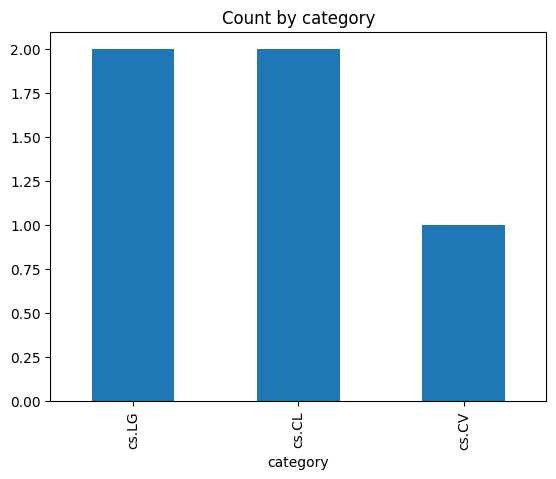

In [6]:
from IPython.display import display
history = df[['title', 'year', 'category']].head(5)
display(history)

counts = df['category'].value_counts()
counts.plot(kind='bar', title='Count by category')
plt.show()

## 5. Налагодження коду в ноутбуці (debug, print, %debug)

Приклад використання assertions та інтерактивного дебагу у клітинці.

In [7]:
assert len(df) > 0, 'Dataset should not be empty'
print('Dataset is valid, rows =', len(df))

# Для демонстрації: запустіть %debug після помилки
# %debug

Dataset is valid, rows = 5


## 6. Параметри та конфігурації через змінні середовища

Показуємо, як зчитувати `.env` та перемикатися між режимами.

In [8]:
try:
    from dotenv import load_dotenv
    load_dotenv()
except ModuleNotFoundError:
    print('python-dotenv is not installed. Install with: pip install python-dotenv')
env = os.getenv('PINECONE_API_KEY', None)
print('PINECONE_API_KEY exists:', env is not None)
mode = os.getenv('APP_ENV', 'dev')
print('APP_ENV =', mode)

python-dotenv is not installed. Install with: pip install python-dotenv
PINECONE_API_KEY exists: False
APP_ENV = dev


## 7. Запуск юніт-тестів і тестування фрагментів коду

Тут показуємо, як запускати `pytest` або тестові функції прямо з ноутбука.

In [9]:
def test_build_texts_nonempty():
    sample = pd.DataFrame([{'title': 'Test', 'abstract': 'Hello world'}])
    assert build_texts(sample) == ['Test [SEP] Hello world']

test_build_texts_nonempty()
print('Simple unit test passed')

# Якщо хочеш, можна запускати pytest: %run -m pytest -q tests

Simple unit test passed


## 8. Профілювання та оптимізація швидкості

Використання `%time`, `%timeit` та `cProfile` для аналізу швидкості.

In [10]:
%timeit build_texts(df)
%timeit embed_texts(['hello world'] * 10)

366 μs ± 50.7 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
Falling back to lightweight embeddings: No module named 'sentence_transformers'


Creating fallback embeddings: 100%|██████████| 10/10 [00:00<00:00, 1225.97it/s]


Falling back to lightweight embeddings: No module named 'sentence_transformers'


Creating fallback embeddings: 100%|██████████| 10/10 [00:00<?, ?it/s]


Falling back to lightweight embeddings: No module named 'sentence_transformers'


...

Falling back to lightweight embeddings: No module named 'sentence_transformers'


Creating fallback embeddings: 100%|██████████| 10/10 [00:00<00:00, 12278.41it/s]


Falling back to lightweight embeddings: No module named 'sentence_transformers'


Creating fallback embeddings: 100%|██████████| 10/10 [00:00<00:00, 9984.06it/s]

4.8 ms ± 374 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


## 9. Експорт ноутбука назад у .py та автоматизація

Показуємо команду для конвертації ноутбука в Python-скрипт та інтеграції в CI.

In [11]:
# Конвертація у скрипт через nbconvert
# !jupyter nbconvert --to script notebook_transition.ipynb
print('Use jupyter nbconvert --to script notebook_transition.ipynb to export')

Use jupyter nbconvert --to script notebook_transition.ipynb to export


## 10. Інтеграція з Git і робота у VSCode (панель виводу, термінал)

Поради для роботи з .ipynb у Git: збереження змін, перегляд дифів та робота через інтегрований термінал.

In [12]:
print('Use Git panel in VSCode for notebook diffs or nbdime for cleaner comparisons.')
print('Run commands in the integrated terminal to keep workflow in one місці.')

Use Git panel in VSCode for notebook diffs or nbdime for cleaner comparisons.
Run commands in the integrated terminal to keep workflow in one місці.
